# FFNN outer - development

In [1]:
from paths import *
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

## Collect multiple PFI
Function to collect and return highest pairwise attr across models (runs)

In [2]:
total_interaction_pairs_df = pd.DataFrame()
for r_num in range(96, 99):
    print(f"Run number: run{r_num}")
    top_interaction_pairs_path = os.path.join(path_to_nn_runs, f"torch_mlp_n400_k12_standard_run{r_num}/","top_interaction_pair_kmers.csv")
    top_interaction_pairs_df = pd.read_csv(top_interaction_pairs_path)
    total_interaction_pairs_df = pd.concat([total_interaction_pairs_df, top_interaction_pairs_df], ignore_index=True)
display(total_interaction_pairs_df)

Run number: run96
Run number: run97
Run number: run98


,feature_index,entity,organism,decoded_kmer
0,5,J96_22_reoriented,bacterium,TAACATACGATC
1,104,J96_22_reoriented,bacterium,GAAGCCACAATG
2,143,J96_22_reoriented,bacterium,AAATTGACATTC
3,190,J96_22_reoriented,bacterium,TAACAGAATTTG
4,315,J96_22_reoriented,bacterium,CTTGTGCTTTTT
...,...,...,...,...
148,3160,J96_22_reoriented,bacterium,TTTGTCCGCGTT
149,3188,J96_22_reoriented,bacterium,GCGCCAACTGCG
150,3189,J96_22_reoriented,bacterium,CTATTGGGTTAA
151,3255,J96_22_reoriented,bacterium,CCTACACCCGGC


,decoded_kmer,abundance
0,TAACATACGATC,3
1,GAAGCCACAATG,3
2,AAATTGACATTC,3
3,TAACAGAATTTG,3
4,CTTGTGCTTTTT,3
5,GCGTCGCACCCG,3
6,AAACCCGATGGC,3
7,TGGGGCACTTTC,3
8,TCTCAGTTCTGG,3
9,GGAATAAAGCTT,3


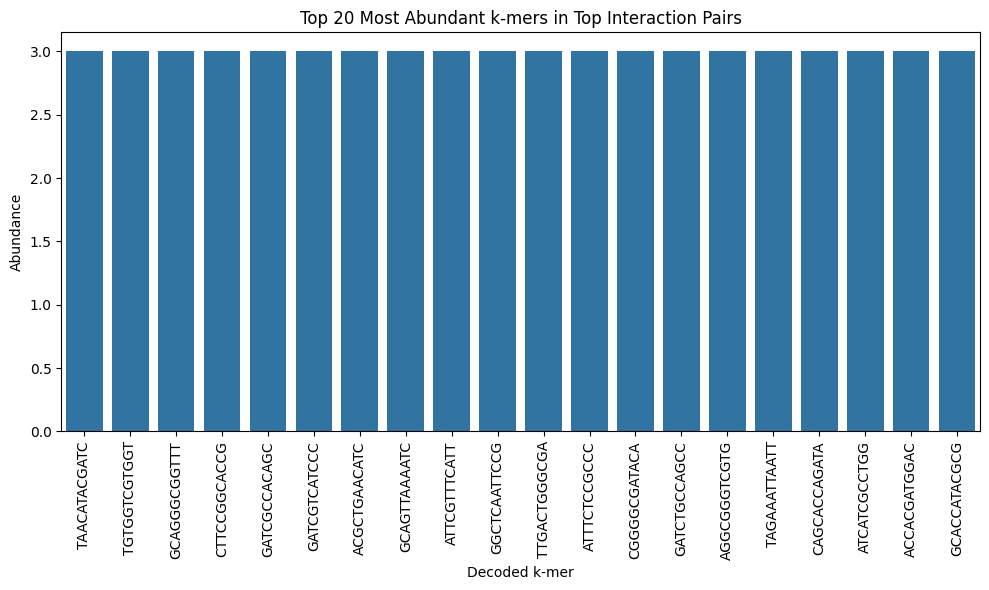

In [3]:
from collections import Counter
kmer_abundance = Counter(total_interaction_pairs_df['decoded_kmer'].tolist())
kmer_abundance_df = pd.DataFrame(kmer_abundance.items(), columns=['decoded_kmer', 'abundance'])
display(kmer_abundance_df)

plt.figure(figsize=(10, 6))
sns.barplot(x='decoded_kmer', y='abundance', data=kmer_abundance_df.sort_values(by='abundance', ascending=False).head(20))
plt.xticks(rotation=90)
plt.title('Top 20 Most Abundant k-mers in Top Interaction Pairs')
plt.xlabel('Decoded k-mer')
plt.ylabel('Abundance')
plt.tight_layout()
plt.show()

In [7]:
outdir = "pfi_interaction_kmers_analysis/"
if not os.path.exists(data_prod_path+outdir):
    os.makedirs(data_prod_path+outdir)

# Aggregate total_interaction_pairs_df by combining "decoded_kmer" column, and recreating the other columns into a list of unique values for each "decoded_kmer"
total_aggr_df = total_interaction_pairs_df.groupby('decoded_kmer').agg({
    'feature_index': lambda x: list(set(x)),
    'entity': lambda x: list(set(x)),
    'organism': lambda x: list(set(x))
}).reset_index()

display(total_aggr_df)
total_aggr_df.to_csv(data_prod_path+outdir+"top_interaction_kmers_aggregated.csv", index=False)

,decoded_kmer,feature_index,entity,organism
0,AAACCCGATGGC,[405],[J96_22_reoriented],[bacterium]
1,AAATTGACATTC,[143],[J96_22_reoriented],[bacterium]
2,AAGAGCGCTGTT,[1317],[J96_22_reoriented],[bacterium]
3,AATATGCAGGTC,[574],[J96_22_reoriented],[bacterium]
4,ACCACGATGGAC,[3076],[J96_22_reoriented],[bacterium]
5,ACGCTGAACATC,[2342],[J96_22_reoriented],[bacterium]
6,AGATCCATGTTG,[1763],[J96_22_reoriented],[bacterium]
7,AGGACTACATGA,[556],[J96_22_reoriented],[bacterium]
8,AGGCGGGTCGTG,[2918],[J96_22_reoriented],[bacterium]
9,ATACTTATGTCC,[691],[J96_22_reoriented],[bacterium]


## Annotate genomes
Function to annotate genomes with protein names

### Using prokka

In [33]:
### Getting info from top interacting k-mers for J96_22

total_aggr_df = pd.read_csv(data_prod_path+"pfi_interaction_kmers_analysis/top_interaction_kmers_aggregated.csv") #aggregated top interaction k-mers with feature indices, entities, and organisms
total_aggr_df = total_aggr_df[total_aggr_df['entity'].apply(lambda x: 'J96_22' in x)] #filter for rows where the entity column contains "J96_22"

display(total_aggr_df.head())

top_int_kmer_entity = dict()
total_aggr = total_aggr_df[["decoded_kmer", "entity"]].to_dict(orient='records') #create a list of dictionaries with decoded_kmer and entity
for ent in total_aggr:
    clean_entity = [e.strip("[]' ") for e in ent["entity"].split(",")] #clean the entity list by removing brackets and quotes
    ent["entity"] = clean_entity
    if ent["decoded_kmer"] not in top_int_kmer_entity:
        top_int_kmer_entity[ent["decoded_kmer"]] = ent["entity"]
    else:
        top_int_kmer_entity[ent["decoded_kmer"]].extend(ent["entity"])

print(top_int_kmer_entity)

,decoded_kmer,feature_index,entity,organism
0,AAACCCGATGGC,[405],['J96_22_reoriented'],['bacterium']
1,AAATTGACATTC,[143],['J96_22_reoriented'],['bacterium']
2,AAGAGCGCTGTT,[1317],['J96_22_reoriented'],['bacterium']
3,AATATGCAGGTC,[574],['J96_22_reoriented'],['bacterium']
4,ACCACGATGGAC,[3076],['J96_22_reoriented'],['bacterium']


{'AAACCCGATGGC': ['J96_22_reoriented'], 'AAATTGACATTC': ['J96_22_reoriented'], 'AAGAGCGCTGTT': ['J96_22_reoriented'], 'AATATGCAGGTC': ['J96_22_reoriented'], 'ACCACGATGGAC': ['J96_22_reoriented'], 'ACGCTGAACATC': ['J96_22_reoriented'], 'AGATCCATGTTG': ['J96_22_reoriented'], 'AGGACTACATGA': ['J96_22_reoriented'], 'AGGCGGGTCGTG': ['J96_22_reoriented'], 'ATACTTATGTCC': ['J96_22_reoriented'], 'ATCATCGCCTGG': ['J96_22_reoriented'], 'ATTCGTTTCATT': ['J96_22_reoriented'], 'ATTTCTCCGCCC': ['J96_22_reoriented'], 'CAGCACCAGATA': ['J96_22_reoriented'], 'CATCTACGGTTT': ['J96_22_reoriented'], 'CCTACACCCGGC': ['J96_22_reoriented'], 'CCTGCGCCCGCA': ['J96_22_reoriented'], 'CCTGTGATAAGA': ['J96_22_reoriented'], 'CGGGGCGATACA': ['J96_22_reoriented'], 'CTATTGGGTTAA': ['J96_22_reoriented'], 'CTCAAAGTGAGC': ['J96_22_reoriented'], 'CTTCCGGCACCG': ['J96_22_reoriented'], 'CTTCGCCGACTT': ['J96_22_reoriented'], 'CTTGTGCTTTTT': ['J96_22_reoriented'], 'GAAACGACATCG': ['J96_22_reoriented'], 'GAAGCCACAATG': ['J96_22

In [34]:
from Bio import SeqIO

J9622_annot_nucl = os.path.join(data_prod_path, "prokka_J96_22/prokka_annotated.ffn") #annotated nucleotide sequences of J96_22

kmer_description_dict = dict()

# Read the J9622_annot_nucl file and create a dictionary with the sequence ID as the key and the sequence as the value
seq_dict = SeqIO.to_dict(SeqIO.parse(J9622_annot_nucl, "fasta"))
for loc_tag in seq_dict.keys():
    #print(seq_dict[loc_tag])
    for kmer, entities in top_int_kmer_entity.items():
        if kmer in str(seq_dict[loc_tag].seq):
            print(f"\nK-mer: {kmer} found in sequence ID: {loc_tag} with entities: {entities}")
            print(f"Description: {seq_dict[loc_tag].description}")
            print(" ".join(seq_dict[loc_tag].description.split(" ")[1:]))
            kmer_description_dict[kmer] = " ".join(seq_dict[loc_tag].description.split(" ")[1:]) #get the second word in the description as the putative function of the k-mer



K-mer: GTGGCTGATATT found in sequence ID: CHAKJNNH_00256 with entities: ['J96_22_reoriented']
Description: CHAKJNNH_00256 Protein-methionine-sulfoxide reductase heme-binding subunit MsrQ
Protein-methionine-sulfoxide reductase heme-binding subunit MsrQ

K-mer: GATCGCCACAGC found in sequence ID: CHAKJNNH_00491 with entities: ['J96_22_reoriented']
Description: CHAKJNNH_00491 HTH-type transcriptional activator RhaR
HTH-type transcriptional activator RhaR

K-mer: GACCGCTTTATC found in sequence ID: CHAKJNNH_00719 with entities: ['J96_22_reoriented']
Description: CHAKJNNH_00719 Glycine dehydrogenase (decarboxylating)
Glycine dehydrogenase (decarboxylating)

K-mer: ATTTCTCCGCCC found in sequence ID: CHAKJNNH_00874 with entities: ['J96_22_reoriented']
Description: CHAKJNNH_00874 Tryptophan-specific transport protein
Tryptophan-specific transport protein

K-mer: GACCGCTTTATC found in sequence ID: CHAKJNNH_00927 with entities: ['J96_22_reoriented']
Description: CHAKJNNH_00927 Cytosine permease
C

In [36]:
kmer_description_dict

{'GTGGCTGATATT': 'Putative glycoside/cation symporter YagG',
 'GATCGCCACAGC': 'Phosphatidylglycerophosphatase C',
 'GACCGCTTTATC': 'Bifunctional protein PutA',
 'ATTTCTCCGCCC': 'Tryptophan-specific transport protein',
 'AAACCCGATGGC': 'Pectinesterase A',
 'TTGACTGGGCGA': 'Endoglucanase 5',
 'GCGCCAACTGCG': 'Argininosuccinate lyase',
 'TGGCGGTTTGGC': 'Inner membrane protein YidH',
 'TCTCAGTTCTGG': 'D-serine/D-alanine/glycine transporter',
 'GATCGTCATCCC': 'Ferric citrate uptake sigma factor regulator FecR',
 'AGATCCATGTTG': '3-deoxy-manno-octulosonate cytidylyltransferase',
 'ACGCTGAACATC': 'Multidrug resistance protein MdtL',
 'CCTGCGCCCGCA': 'Type VI secretion system sheath protein TssC1',
 'ATCATCGCCTGG': 'Respiratory nitrate reductase 1 alpha chain',
 'CGGGGCGATACA': 'Lon protease',
 'GCGAAAAAAATT': 'Octopine transport system permease protein OccM',
 'GAAACGACATCG': 'hypothetical protein',
 'GCACCATACGCG': 'Ribose import permease protein RbsC'}

In [37]:
total_aggr_df["prokka_protein"] = total_aggr_df["decoded_kmer"].map(kmer_description_dict)
display(total_aggr_df)
total_aggr_df.to_csv(data_prod_path+outdir+"top_interaction_kmers_aggregated.csv", index=False)

,decoded_kmer,feature_index,entity,organism,prokka_protein
0,AAACCCGATGGC,[405],['J96_22_reoriented'],['bacterium'],Pectinesterase A
1,AAATTGACATTC,[143],['J96_22_reoriented'],['bacterium'],NaN
2,AAGAGCGCTGTT,[1317],['J96_22_reoriented'],['bacterium'],NaN
3,AATATGCAGGTC,[574],['J96_22_reoriented'],['bacterium'],NaN
4,ACCACGATGGAC,[3076],['J96_22_reoriented'],['bacterium'],NaN
5,ACGCTGAACATC,[2342],['J96_22_reoriented'],['bacterium'],Multidrug resistance protein MdtL
6,AGATCCATGTTG,[1763],['J96_22_reoriented'],['bacterium'],3-deoxy-manno-octulosonate cytidylyltransferase
7,AGGACTACATGA,[556],['J96_22_reoriented'],['bacterium'],NaN
8,AGGCGGGTCGTG,[2918],['J96_22_reoriented'],['bacterium'],NaN
9,ATACTTATGTCC,[691],['J96_22_reoriented'],['bacterium'],NaN


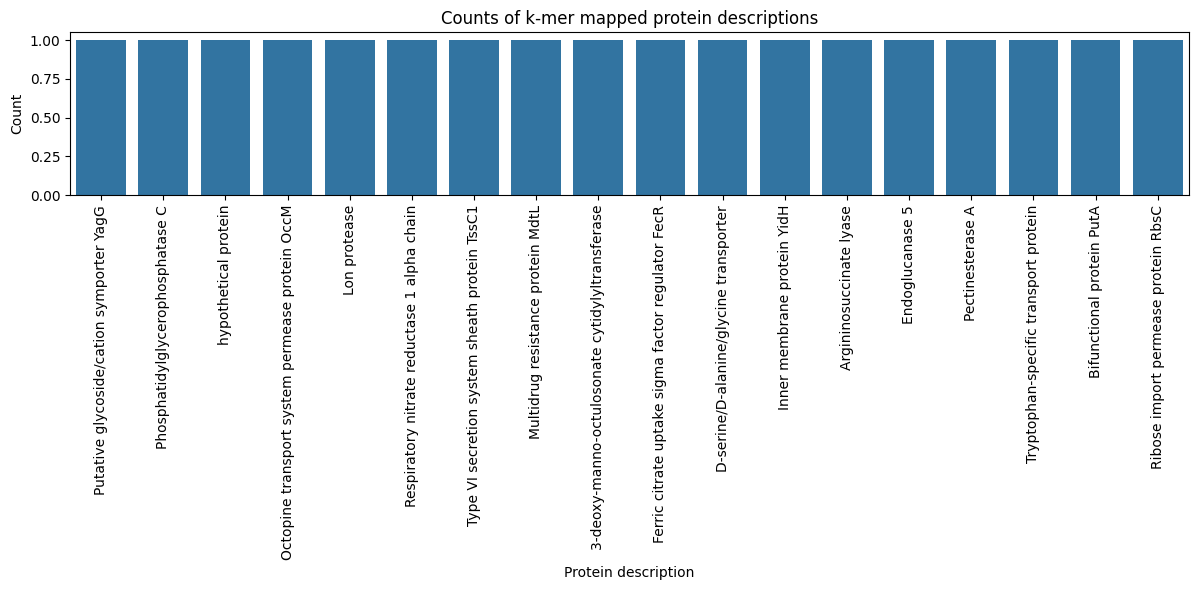

,description,count
0,Putative glycoside/cation symporter YagG,1
1,Phosphatidylglycerophosphatase C,1
2,hypothetical protein,1
3,Octopine transport system permease protein OccM,1
4,Lon protease,1
5,Respiratory nitrate reductase 1 alpha chain,1
6,Type VI secretion system sheath protein TssC1,1
7,Multidrug resistance protein MdtL,1
8,3-deoxy-manno-octulosonate cytidylyltransferase,1
9,Ferric citrate uptake sigma factor regulator FecR,1


In [31]:
if kmer_description_dict:
    description_counts = (
        pd.Series(list(kmer_description_dict.values()), name="description")
        .value_counts()
        .reset_index()
    )
    description_counts.columns = ["description", "count"]

    plt.figure(figsize=(12, 6))
    sns.barplot(data=description_counts, x="description", y="count")
    plt.xticks(rotation=90)
    plt.xlabel("Protein description")
    plt.ylabel("Count")
    plt.title("Counts of k-mer mapped protein descriptions")
    plt.tight_layout()
    plt.show()

    display(description_counts)
else:
    print("kmer_description_dict is empty.")

### Using Empathi
Embedding-based Phage Protein Annotation Tool by Hierarchical Assignment - https://www.nature.com/articles/s41467-025-64177-5

## Map Kmers to Protein name
Function to map kmer to location in genome, outputting annotated protein it's part of.\
input: top_interaction_pair_kmers.csv from each run

## Iter Runs - Closer look

In [ ]:
PFI_parallel_dir = os.path.join(path_to_nn_runs, "iter_excl_PFI_parallel/")
#os.listdir(PFI_parallel_dir)

failed_runs = []
passed_runs = []
for res_dir in os.listdir(PFI_parallel_dir):
    log_files = [f for f in os.listdir(os.path.join(PFI_parallel_dir, res_dir)) if f.startswith("log_run") and f.endswith(".txt")]
    for log_file in log_files:
        log_path = os.path.join(PFI_parallel_dir, res_dir, log_file)
        with open(log_path, "r") as f:
            log_content = f.read()
            #use regex to find "ERROR - No positive values in test" in log_content
            if "ERROR - No positive values in test" in log_content:
                #print(f"Found error in {log_path}")
                failed_runs.append(res_dir)
            else:
                passed_runs.append(res_dir)

print(f"Failed runs {len(failed_runs)}: {failed_runs}")
print(f"Passed runs {len(passed_runs)}: {passed_runs}")

Failed runs 27: ['cluster_b3_p11_run1', 'cluster_b3_p14_run1', 'cluster_b3_p15_run1', 'cluster_b3_p2_run1', 'cluster_b3_p3_run1', 'cluster_b3_p4_run1', 'cluster_b3_p6_run1', 'cluster_b3_p8_run1', 'cluster_b3_p9_run1', 'cluster_b6_p11_run1', 'cluster_b6_p14_run1', 'cluster_b6_p15_run1', 'cluster_b6_p2_run1', 'cluster_b6_p3_run1', 'cluster_b6_p4_run1', 'cluster_b6_p6_run1', 'cluster_b6_p9_run1', 'cluster_b6_p8_run1', 'cluster_b7_p11_run1', 'cluster_b7_p14_run1', 'cluster_b7_p15_run1', 'cluster_b7_p2_run1', 'cluster_b7_p3_run1', 'cluster_b7_p4_run1', 'cluster_b7_p6_run1', 'cluster_b7_p8_run1', 'cluster_b7_p9_run1']
Passed runs 109: ['cluster_b0_p1_run1', 'cluster_b0_p10_run1', 'cluster_b0_p0_run1', 'cluster_b0_p11_run1', 'cluster_b0_p12_run1', 'cluster_b0_p13_run1', 'cluster_b0_p14_run1', 'cluster_b0_p15_run1', 'cluster_b0_p16_run1', 'cluster_b0_p2_run1', 'cluster_b0_p3_run1', 'cluster_b0_p4_run1', 'cluster_b0_p5_run1', 'cluster_b0_p6_run1', 'cluster_b0_p7_run1', 'cluster_b0_p9_run1', 'cl

### Statistics on runs

b value distribution: Counter({3: 17, 6: 17, 7: 17, 0: 17, 1: 17, 2: 17, 4: 17, 5: 17})
p value distribution: Counter({11: 8, 14: 8, 15: 8, 2: 8, 3: 8, 4: 8, 6: 8, 8: 8, 9: 8, 1: 8, 10: 8, 0: 8, 12: 8, 13: 8, 16: 8, 5: 8, 7: 8})


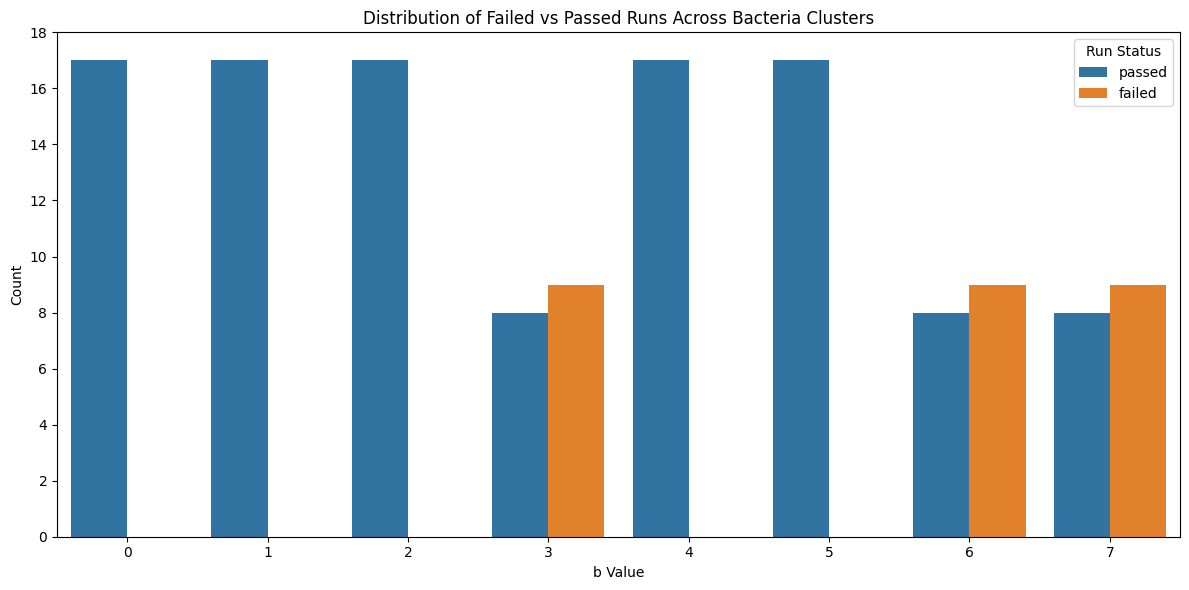

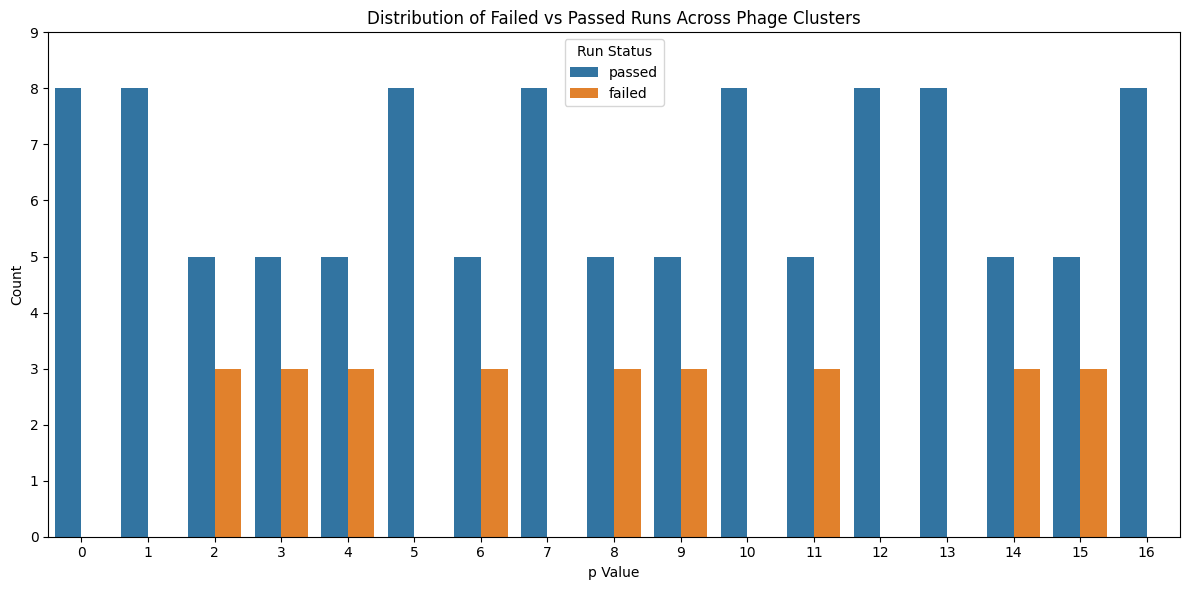

In [16]:
### Obtain distribution of failed vs passed runs across b and p values
from collections import Counter
import re
b_values = []
p_values = []
for run in failed_runs + passed_runs:
    b_match = re.search(r"b(\d+)", run)
    p_match = re.search(r"p(\d+)", run)
    if b_match and p_match:
        b_values.append(int(b_match.group(1)))
        p_values.append(int(p_match.group(1)))
b_counter = Counter(b_values)
p_counter = Counter(p_values)
print(f"b value distribution: {b_counter}")
print(f"p value distribution: {p_counter}")


### Plotting the distribution of failed vs passed runs across b and p values
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd 
# Create a DataFrame for plotting
data = {
    "b_value": b_values,
    "p_value": p_values,
    "status": ["failed"] * len(failed_runs) + ["passed"] * len(passed_runs)
}
df = pd.DataFrame(data)
# Plotting
plt.figure(figsize=(12, 6))
sns.countplot(x="b_value", hue="status", data=df)
plt.title("Distribution of Failed vs Passed Runs Across Bacteria Clusters")
plt.xlabel("b Value")
plt.ylabel("Count")
plt.ylim(0, max(b_counter.values()) + 1)
plt.legend(title="Run Status")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
sns.countplot(x="p_value", hue="status", data=df)
plt.title("Distribution of Failed vs Passed Runs Across Phage Clusters")
plt.xlabel("p Value")
plt.ylabel("Count")
plt.ylim(0, max(p_counter.values()) + 1)
plt.legend(title="Run Status")
plt.tight_layout()
plt.show()

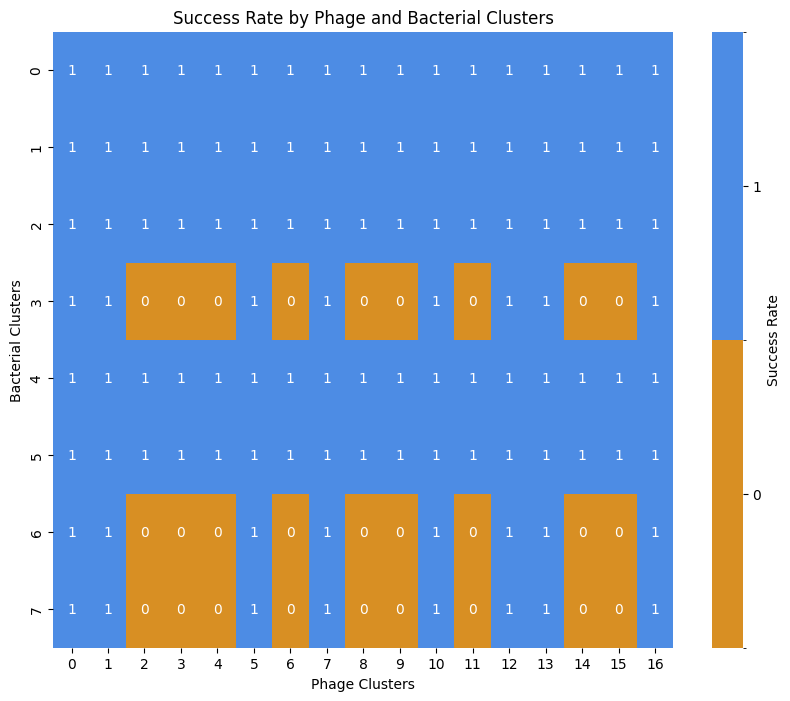

In [ ]:
def plot_b_p_heatmap(df):
    from matplotlib.colors import ListedColormap, BoundaryNorm

    # Calculate success rate for each combination
    heatmap_data = df.groupby(['b_value', 'p_value'])['status'].value_counts(normalize=True).unstack().fillna(0)
    # We only care about the 'passed' percentage
    passed_rate = heatmap_data['passed'].unstack()

    plt.figure(figsize=(10, 8))
    cmap = ListedColormap(["#D4840DE8", "#2E78E0D9"])  # muted orange, muted blue
    norm = BoundaryNorm([-0.5, 0.5, 1.5], cmap.N)

    sns.heatmap(
        passed_rate,
        annot=True,
        fmt=".0f",
        cmap=cmap,
        norm=norm,
        cbar_kws={"label": "Success Rate", "ticks": [0, 1]}
    )

    plt.title("Success Rate by Phage and Bacterial Clusters")
    plt.xlabel("Phage Clusters")
    plt.ylabel("Bacterial Clusters")
    plt.show()

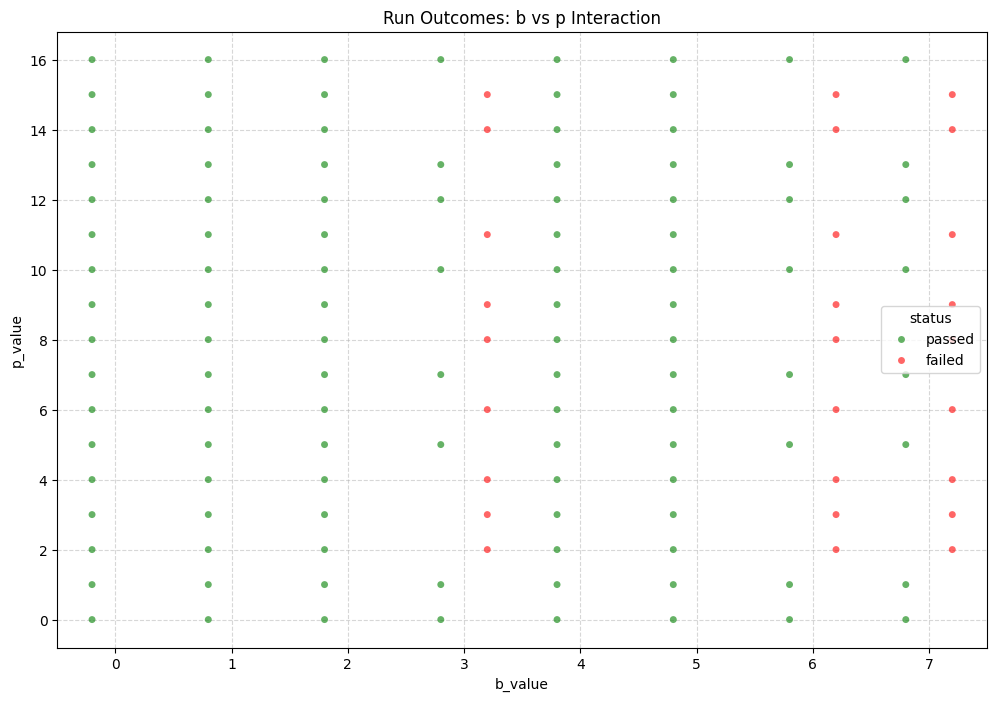

In [33]:
plt.figure(figsize=(12, 8))
sns.stripplot(data=df, x="b_value", y="p_value", hue="status", 
              palette={"passed": "green", "failed": "red"}, 
              dodge=True, alpha=0.6, jitter=0)
plt.title("Run Outcomes: b vs p Interaction")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

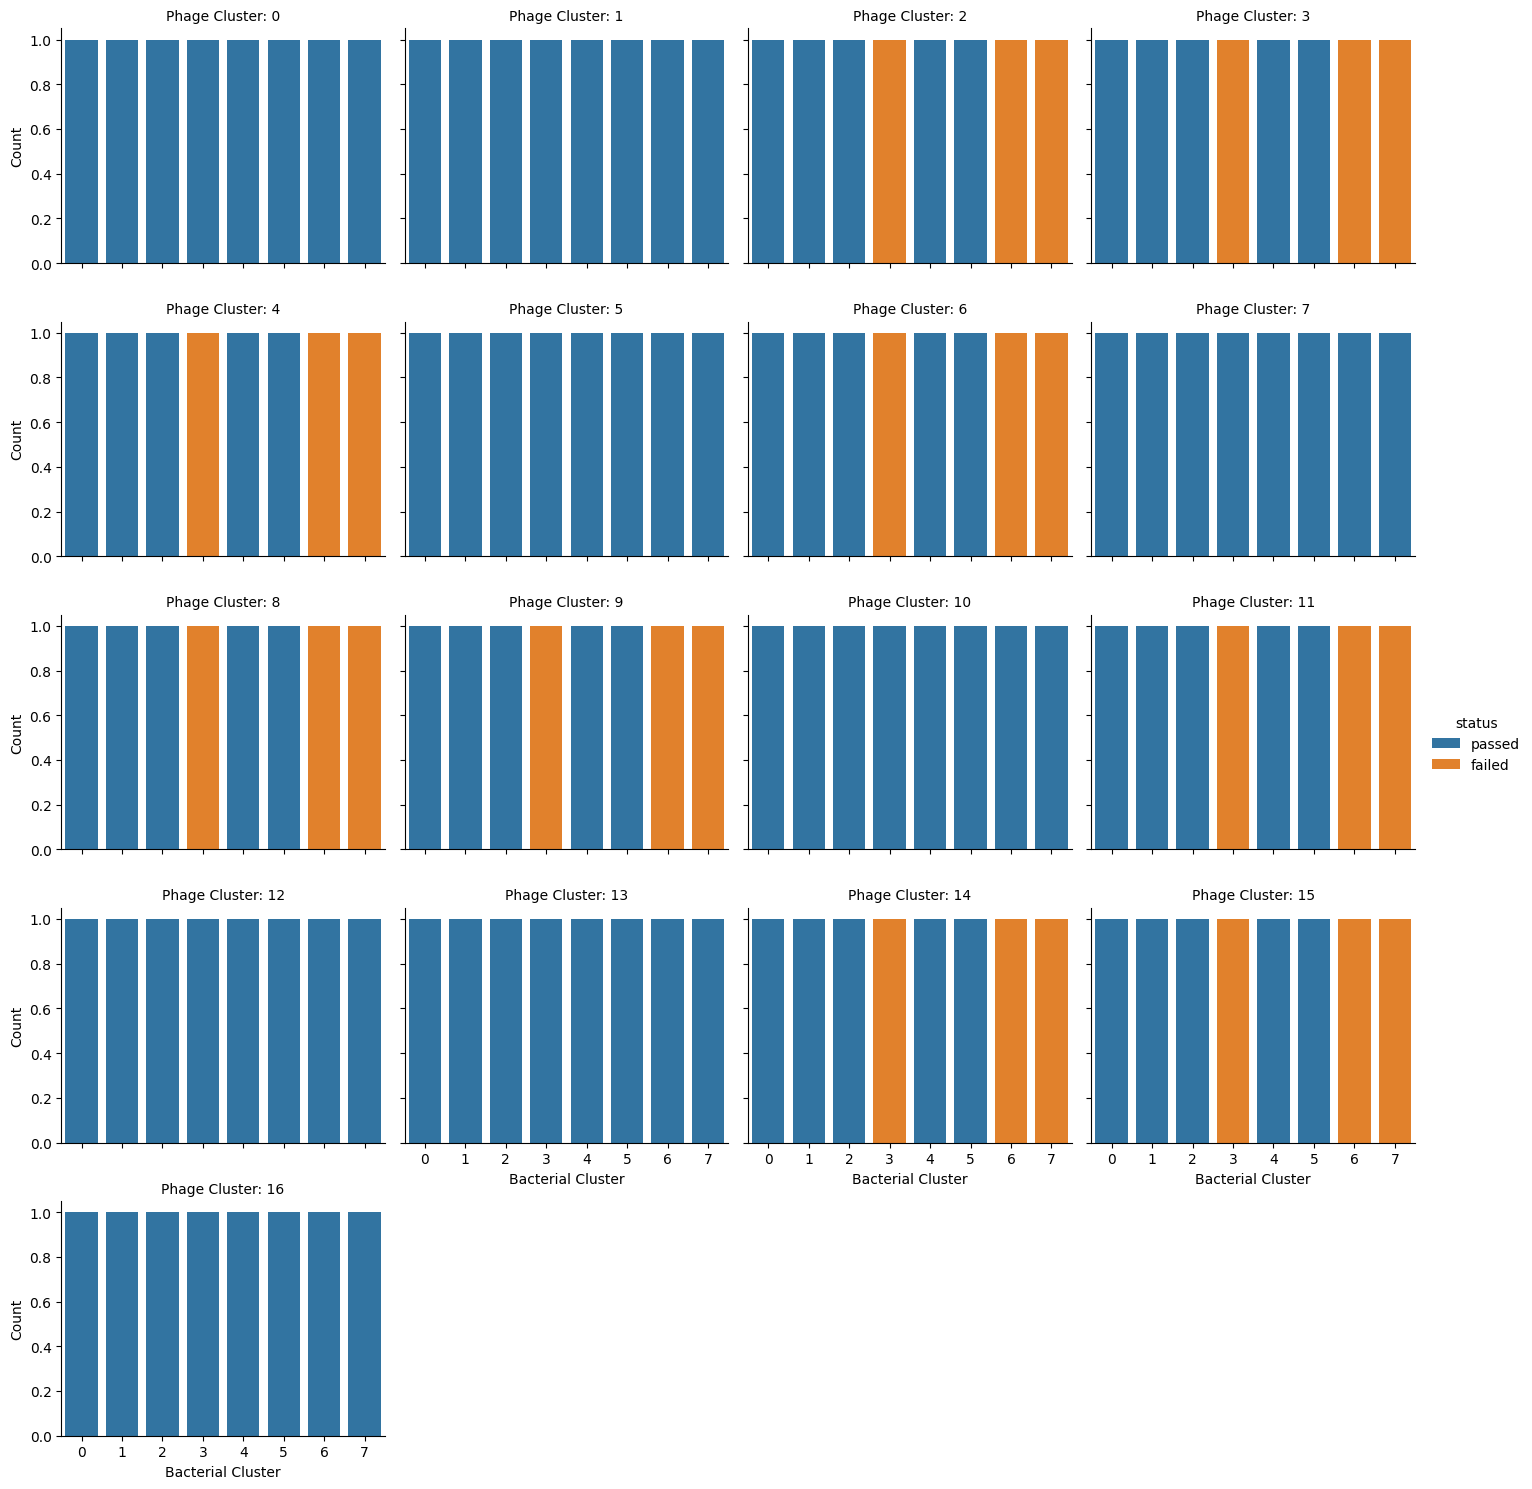

In [35]:
g = sns.catplot(
    data=df, x="b_value", hue="status", col="p_value",
    kind="count", col_wrap=4, height=3, aspect=1.2
)
g.set_axis_labels("Bacterial Cluster", "Count")
g.set_titles("Phage Cluster: {col_name}")
plt.show()